In [50]:
from pyfiles.ftsteane import *
from HPC.Upload.classes import *
from random import choices
import math
import cmath
import itertools

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.sans-serif": "Helvetica",
})

In [47]:
def breakeven(p: int, n: int, x: list):       #p: Error probability, n: physical qubits per log. qubit, x: list with k Layers of n-qubit transversal gates
    log_err = []
    for k in x:
        term1 = (1-p)**(k*(n-1))
        term2 = (1+p*(n-1))**k
        log_err.append(1 - term1*term2)
    return log_err

In [48]:
p , p1, p2,  n = 0.01, 0.001, 0.0001, 9

x = [i for i in range(300)]
y, y1, y2 = breakeven(p, n, x), breakeven(p1, n, x), breakeven(p2, n, x)

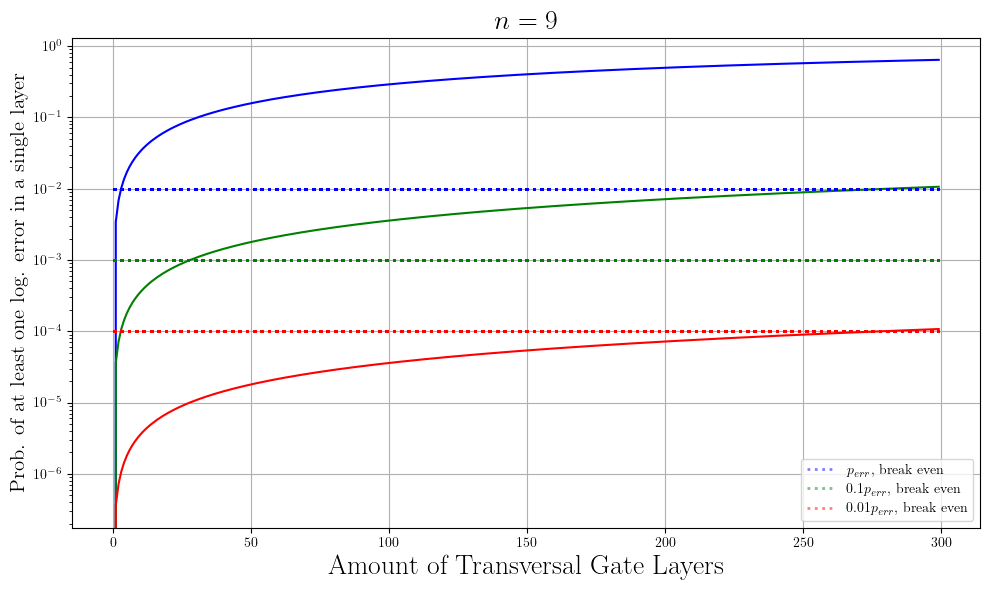

In [49]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(x,y,color="blue"), plt.plot(x,y1,color="green"), plt.plot(x,y2,color="red")
ax1.hlines([p for i in range(len(x))], min(x), max(x), color = "blue", linestyles=":", label=r"$p_{err}$, break even", linewidth=2, alpha=0.5)
ax1.hlines([p1 for i in range(len(x))], min(x), max(x), color = "green", linestyles=":", label=r"$0.1p_{err}$, break even", linewidth=2, alpha=0.5)
ax1.hlines([p2 for i in range(len(x))], min(x), max(x), color = "red", linestyles=":", label=r"$0.01p_{err}$, break even", linewidth=2, alpha=0.5)
ax1.set_xlabel("Amount of Transversal Gate Layers", fontsize=20)
ax1.set_ylabel("Prob. of at least one log. error in a single layer", fontsize=15)
ax1.set_yscale("log")
ax1.set_title(rf"$n = {n}$", fontsize=20)
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

In [51]:
code = "steane"    #"steane", "phaseflip", "rotsurf"
x = np.linspace(0.00005, 0.0001, 5)
y, y_qec = [], []
layers = 10
shots = 10000
bias = 0
for i in x:
    #dustin_qec = RepCode_z(3,1)
    if code == "rotsurf":
        dustin_qec = RotSurf9q(1,0)
    elif code == "steane":
        dustin_qec = Steane7q(1,0)
    else:
        dustin_qec = RepCode_z(3,1)
    dustin_qec.err = True
    dustin_qec.postselection = True
    for k in range(layers):
        dustin_qec.qec(0)
        # if k == 5:
        #     dustin_qec.qec(0)
        # if k == 10:
        #     dustin_qec.qec(0)
        # if k != 0 and (k+1)%6 == 0:
        #      dustin_qec.qec(0)
            #  dustin_qec.qec(0)
    # dustin_qec.qec(0)
    dustin_qec.readout(0, shots, i)
    y_qec.append(1-dustin_qec.zeros/(dustin_qec.zeros+dustin_qec.ones))

print("Zeros: ", dustin_qec.zeros)
print("Ones: ", dustin_qec.ones)
if code == "rotsurf" or code == "steane":
    print("Preselection: ", dustin_qec.preselected)
print("Postselection: ", dustin_qec.post)

Zeros:  0.9965
Ones:  0.0017
Preselection:  0.0004
Postselection:  0.0014


[0.0013009106374461954, 0.0009013520280420906, 0.0020028039254956775, 0.00110198357042679, 0.0017030655179323118]


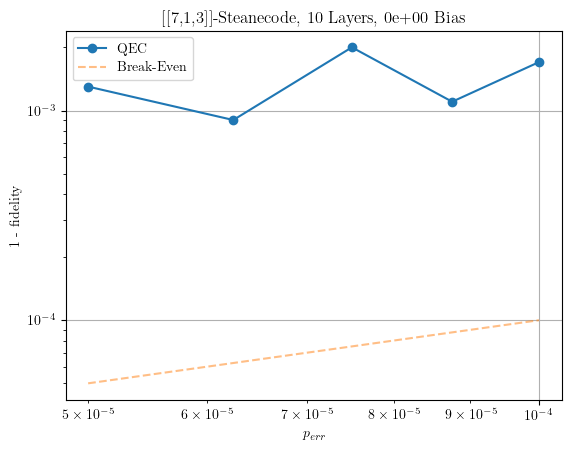

In [52]:
# print(y)
print(y_qec)

y_even = x.copy()
# plt.plot(x,y,marker="x",label="No QEC")
plt.plot(x,y_qec,marker="o",label="QEC")
plt.plot(x,y_even,linestyle="--",label="Break-Even",alpha=0.5)
plt.grid()
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"1 - fidelity")
plt.xlabel(r"$p_{err}$")
if code == "rotsurf":
    plt.title("[[9,1,3]]-RotSurfCode, {} Layers, {:.0e} Bias".format(layers, bias))
elif code == "steane":
    plt.title("[[7,1,3]]-Steanecode, {} Layers, {:.0e} Bias".format(layers, bias))
else:
    plt.title("[[3,1,3]]-Phaseflipcode, {} Layers, {:.0e} Bias".format(layers, bias))

plt.show()

In [ ]:
dustin = RotSurf9q(1,0)

gates(dustin.qc)

dustin.qec(0)

gates(dustin.qc)

Amount of gates in this circuit:  12
Amount of gates in this circuit:  44
